# Run cells from AllenDB

In [1]:
import os, sys, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# Lightweight bootstrap for kernels launched outside repo root.
try:
    from modules_local.notebook_helpers import ensure_scp_repo_on_syspath, ensure_external_repo_on_syspath
except ModuleNotFoundError:
    start = Path.cwd().resolve()
    injected = False
    for cand in (start, *start.parents):
        if (cand / "modules_local").is_dir() and (cand / "run_pipeline.py").is_file():
            if str(cand) not in sys.path:
                sys.path.insert(0, str(cand))
            injected = True
            break

    if not injected:
        for base in (start, start.parent):
            try:
                for child in base.iterdir():
                    if child.is_dir() and (child / "modules_local").is_dir() and (child / "run_pipeline.py").is_file():
                        if str(child) not in sys.path:
                            sys.path.insert(0, str(child))
                        injected = True
                        break
                if injected:
                    break
            except Exception:
                pass

    from modules_local.notebook_helpers import ensure_scp_repo_on_syspath, ensure_external_repo_on_syspath

repo_root = ensure_scp_repo_on_syspath()

from modules_local import run_sim

act_path = ensure_external_repo_on_syspath(
    repo_name='ACT',
    marker_rel=Path('act') / 'passive.py',
    env_vars=('SCP_ACT_PATH', 'ACT_PATH', 'ACT_ROOT'),
    repo_root=repo_root,
)

from act.passive import ACTPassiveModule


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


# Local Cell Bundle

### Validate Local Cell Bundle (prepared in Step 0)

In [2]:
cell_name = 'SST' # SST, SST_0, PV
model_dir = 'seg_tuned_all' # seg_tuned_all

cell_dir = repo_root / 'cells' / cell_name
if not cell_dir.is_dir():
    raise FileNotFoundError(f"Cell directory not found: {cell_dir}")
os.chdir(cell_dir)
print('CWD:', Path.cwd())


cfg_path = Path('tunes') / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path('tunes') / model_dir / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = repo_root / 'cells' / cell_name / 'tunes' / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = repo_root / 'cells' / cell_name / 'tunes' / model_dir / "sim_config.json"
if cfg_path.is_file():
    sim_cfg_preview = json.loads(cfg_path.read_text())

bundle_dir = Path('tunes') / model_dir
required_paths = [
    bundle_dir / "manifest.json",
    bundle_dir / "modfiles",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    missing_text = "\n".join(missing)
    raise FileNotFoundError(
        f"Missing required local cell bundle files:\n{missing_text}\n"
        "Prepare/download the bundle in Step 0, then rerun this notebook."
    )

print(f"Using existing local model bundle: {bundle_dir.resolve()}")



CWD: /home/hrbncv/SCP/cells/SST
Using existing local model bundle: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned_all


### Load Precompiled Mechanisms (from Step 0)

In [3]:
tune_dir = repo_root / 'cells' / cell_name / 'tunes' / model_dir
if not tune_dir.is_dir():
    raise FileNotFoundError(f"Tune directory not found: {tune_dir}")
os.chdir(tune_dir)

from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()

mech_candidates = [
    Path("modfiles/x86_64/.libs/libnrnmech.so"),
    Path("modfiles/x86_64/libnrnmech.so"),
]

mech_path = next((p for p in mech_candidates if p.is_file()), None)
if mech_path is None:
    raise FileNotFoundError(
        "Could not find compiled NEURON mechanisms. Expected one of: "
        + ", ".join(str(p) for p in mech_candidates)
        + "\nRun Step 0 to compile modfiles, or use the Colab notebook variant that bootstraps compilation."
    )

h.nrn_load_dll(str(mech_path))
print(f"Loaded mechanisms: {mech_path}")


Loaded mechanisms: modfiles/x86_64/.libs/libnrnmech.so


# Build the cell

In [4]:
from modules_local.notebook_helpers import (
    build_cell_for_notebook,
    resolve_cell_config_for_notebook,
)

cell_config_for_build = resolve_cell_config_for_notebook(cell_name)
soma_diam_multiplier = float(cell_config_for_build['tuning']['soma_diam_multiplier'])
cell = build_cell_for_notebook(cell_config_for_build)

sect = cell.h.soma[0]
seg = 0.5
print(f"{sect}: A={round(sect(seg).area(),2)} | D={round(sect.diam)} | L={round(sect.L)}")


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=10.0, Vinit=-65.0, loader=genome_fallback
soma[0]: A=5739.13 | D=135 | L=14


# Tuning Active Properties

## 1. ACT Tuning
### A. LTO Module
### B. Spiking Module
### C. Bursting Module


## 2. Multi-Sim Plot

na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=10.0, Vinit=-65.0, loader=genome_fallback
50 pA spike frequency = 34.00 Hz
75 pA spike frequency = 41.00 Hz
100 pA spike frequency = 47.00 Hz


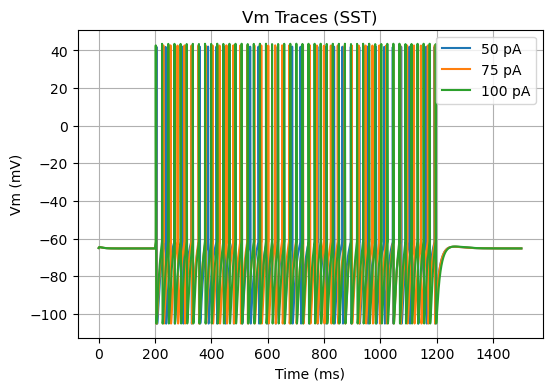

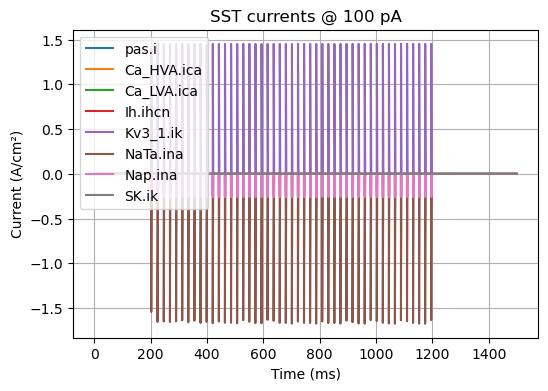

In [5]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
sim_amps = [50,75,100]

from modules_local.notebook_helpers import build_cell_for_notebook
cell = build_cell_for_notebook(cell_config_for_build)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)

# Analyze and plot each run
plt.figure(figsize=(6,4))
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name})")
window = (None, None) # (start, end) in ms, or None for auto
plt.xlim(window[0],window[1])
# plt.ylim(-68.2,-67.8)
plt.legend(),plt.grid(),plt.show()



ampsel = sim_amps[-1]
currents = [] # add specific currents to list
run_sim.plot_looped_currents(cell_name,ampsel,currents,looped_records,window)


### 3. Generate FI Curve

na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                

           ^


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=10.0, Vinit=-65.0, loader=genome_fallback


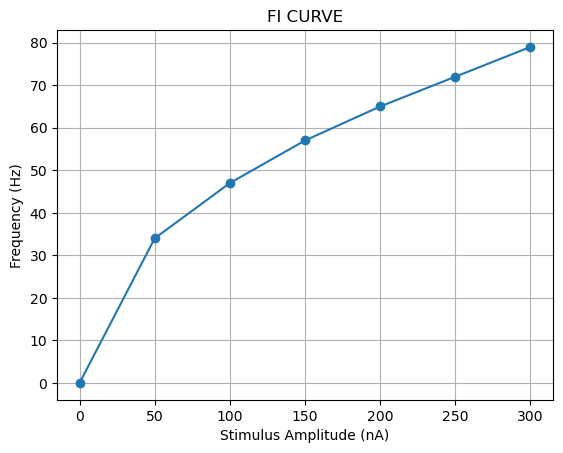

In [6]:
#set simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }

#test the cell at multiple currents to get an FI curve
amp_range = (0, 300, 50) # (start, end, step)
amps = list(np.arange(amp_range[0], amp_range[1] + amp_range[2]/2, amp_range[2]))

from modules_local.notebook_helpers import build_cell_for_notebook
cell = build_cell_for_notebook(cell_config_for_build)
freq_recs = run_sim.run_FI(cell,sim_params,amps)


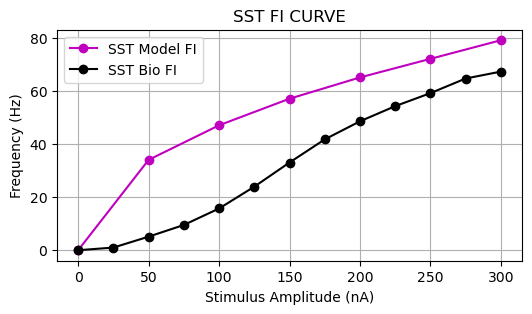

In [7]:
amps = [amp for amp in amps]
freqs = [freq_recs[amp] for amp in freq_recs]
bio_FI_data = {
    'SST': [(00,0),(25,1),(50,5.1),(75,9.5),(100,15.7),(125,23.9),(150,33),(175,41.7),(200,48.5),(225,54.2),(250,59.1),(275,64.6),(300,67.2)],
    'PV': [(00,0),(25,0),(50,0),(75,0.1),(100,3.3),(125,6.2),(150,12.9),(175,19.7),(200,27.9),(225,35.2),(250,44.8),(275,55.5),(300,57.4)]
}
if bio_FI_data[cell_name]:
    bio_FI = bio_FI_data[cell_name]
    bio_amps = []
    bio_freqs = []

    for FI in bio_FI:
        bio_amps.append(FI[0])
        bio_freqs.append(FI[1])


    plt.figure(figsize=(6,3))
    plt.plot(amps, freqs, marker='o', color = 'm',label = f'{cell_name} Model FI')
    plt.plot(bio_amps,bio_freqs,marker = 'o', color = 'k', label = f'{cell_name} Bio FI')
    plt.title(f"{cell_name} FI CURVE")
    plt.xlabel("Stimulus Amplitude (nA)"),plt.ylabel("Frequency (Hz)")
    plt.legend(),plt.grid(),plt.show()